### **Yogyakarta's Air Quality Dataset in October 2021**

In [1]:
import pandas as pd

df = pd.read_csv("10-jogja-oct-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,10/1/2021,00:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
2,10/1/2021,01:00:00,19.0,35.0,0.0,7.0,5.0,4.0,35,PM2.5,Good
3,10/1/2021,02:00:00,18.0,34.0,0.0,7.0,6.0,4.0,34,PM2.5,Good
4,10/1/2021,03:00:00,16.0,30.0,0.0,7.0,7.0,4.0,30,PM2.5,Good
5,10/1/2021,04:00:00,16.0,30.0,0.0,7.0,8.0,4.0,30,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,10/31/2021,19:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
741,10/31/2021,20:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
742,10/31/2021,21:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
743,10/31/2021,22:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 10-jogja-oct-2021.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    object 
 1   Time                744 non-null    object 
 2   PM10                741 non-null    float64
 3   PM2.5               741 non-null    float64
 4   SO2                 741 non-null    float64
 5   CO                  741 non-null    float64
 6   O3                  675 non-null    float64
 7   NO2                 741 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  741 non-null    object 
 10  Category            744 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 64.1+ KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 10-jogja-oct-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,741.000000,741.000000,741.000000,741.000000,675.000000,741.000000,744.000000
mean,13.167341,24.009447,5.834008,7.932524,17.642963,4.242915,29.498656
std,3.191892,5.218591,7.817391,3.253403,19.486926,1.480630,12.124078
min,7.000000,13.000000,0.000000,4.000000,0.000000,0.000000,0.000000
25%,11.000000,20.000000,0.000000,6.000000,3.000000,4.000000,22.000000
50%,13.000000,23.000000,2.000000,7.000000,10.000000,4.000000,25.000000
75%,15.000000,28.000000,9.000000,9.000000,26.500000,5.000000,32.000000
max,23.000000,41.000000,27.000000,16.000000,69.000000,7.000000,69.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 10-jogja-oct-2021.csv


Critical Component
PM2.5    69.635628
O3       27.125506
SO2       3.238866
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 10-jogja-oct-2021.csv


Category
Good        90.053763
Moderate     9.946237
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>


##### <span style="color:blue">**1. Line Graph**</span>

Data source: 10-jogja-oct-2021.csv


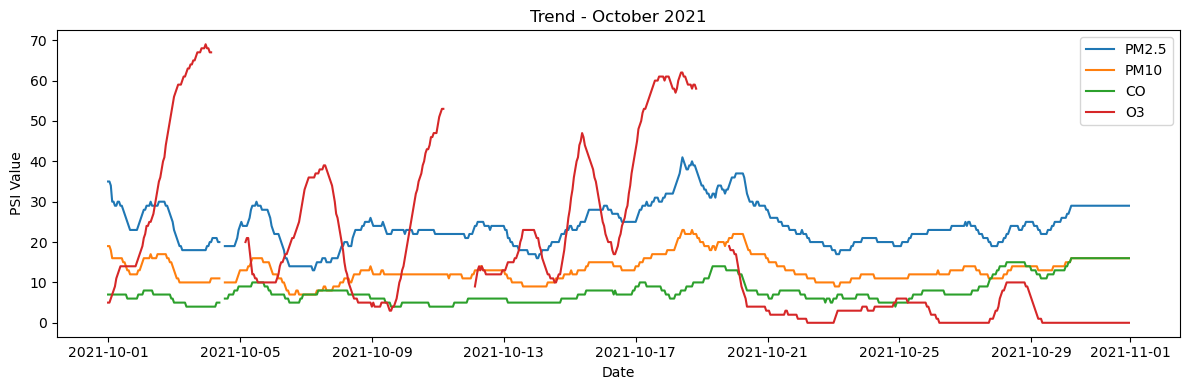

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - October 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In October 2021, O3 went up and down the most and reached the highest peak (about 69 around October 3), while PM2.5 stayed mostly between 15 and 40. PM10 and CO stayed low, and after October 20, O3 stayed near zero.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 10-jogja-oct-2021.csv


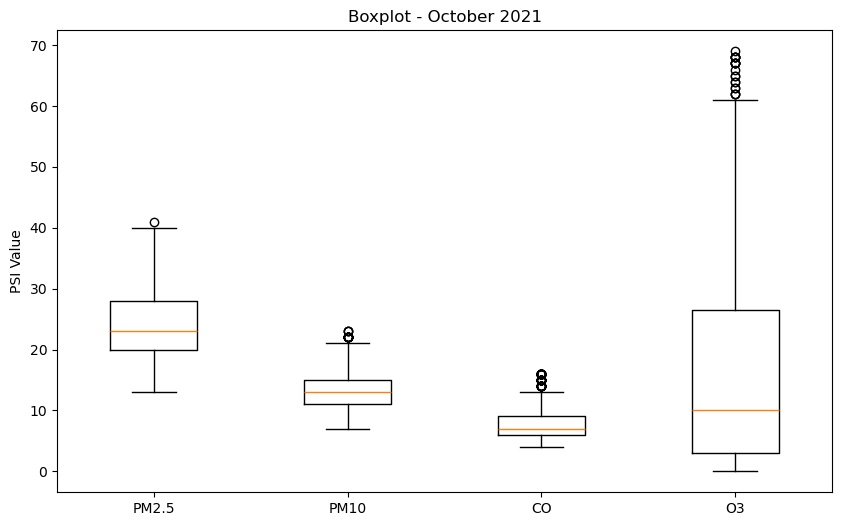

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - October 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In October 2021, O3 spread out the most and had many high outliers (up to about 69), while PM2.5 had the highest median (23) with only one outlier. PM10 and CO stayed low and had a few outliers.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 10-jogja-oct-2021.csv


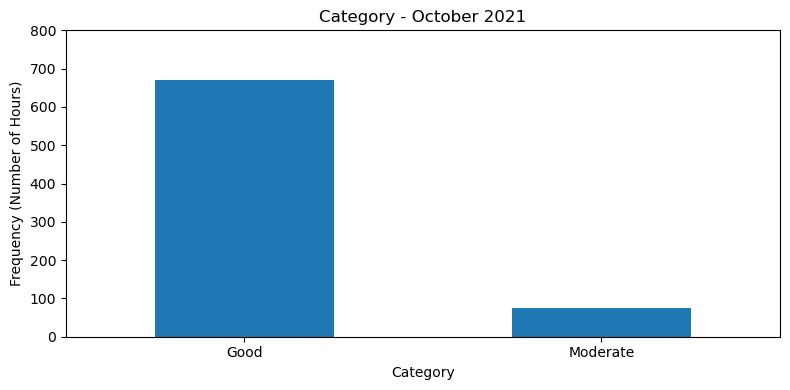

Category
Good        670
Moderate     74
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - October 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

Data source: 10-jogja-oct-2021.csv


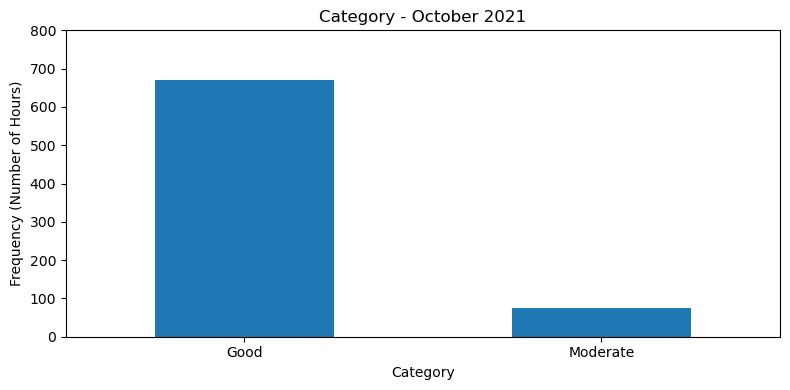

Category
Good        670
Moderate     74
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - October 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category